# Homework 1
### ASTR 324, Spring 2026, Ivezic, University of Washington

https://github.com/uw-astr-324/astr-324-s26


## Homework submission procedure: 

* You will be sending me your executed (with all the plots etc) *.ipynb files via email

* the Subject: line **must be** "astr-324-s26-FirstLast-HW?, where FirstLast is your first
and last name, and ? will be 1, 2, 3 or 4. 

* For example: astr-324-s26-ZeljkoIvezic-HW1

* I will be recognizing and downloading your submissions using a script. If you don't 
follow the above, your HW will not be recognized.

* Your homework email **must be sent** before Thursday class (that is, before 10am)
two weeks after that homework was assigned (e.g. HW1 will be available by the start of Thursday 
class on April 9, and will be due by 10am on April 23).



## Problem 1
* Generate a sample of 10,000 data values drawn from N($\mu$=1.0, $\sigma$=0.2)and draw a pretty histogram
with the bin size determined using the Freedman-Diaconis rule. Show (Poissonian) uncertainty ($N_{bin} \pm \sqrt{N_{bin}}$, where $N_{bin}$ is the count in a given bin) for each histogram value, and overplot the true distribution.


## Problem 2
* Do the same for a Cauchy distribution with the same $\mu$ and $\gamma$=0.2.

## Problem 3
* Compute mean and its uncertainty for both samples and comment on their differences. 

## Problem 4:
Four different studies measured the abundance of planetary systems around main sequence stars of different spectral types (&lt;F, G, K, &gt;M). What is the probability a randomly chosen (== typical) main sequence star will harbor a planetary system? Hint: use the law of total probabilities. 

|Spectral type|Fraction with systems|Fraction of MS stars with this spectral type|
| --- | ---- | ---  |
| < F | 0.1  | 0.1  |
|   G | 0.3  | 0.15 |
|   K | 0.45 | 0.25 |
| > M | 0.7  | 0.5  |

(note: the numbers in this table above are for illustration only, and do not correspond to actual observed rates).

## Problem 5:
* Generate a sample of 100 data values drawn from N($\mu$=1.0, $\sigma$=0.1). Draw 3 values from N($\mu$=10.0, $\sigma$=1.0) and add them to the first sample. Compute the mean and median values for this extended sample 
and discuss how similar they are. 

## Problem 6:
* You are playing a game show and are shown 2 doors.  One has a car behind it, the other a goat.  What are your chances of picking the door with the car (assumed to be much more valuable than goat)?

## Problem 7:
* Now there are 3 doors: one with a car, two with goats. The game show host asks you to pick a door, but not to open it yet. Then the host opens one of the other two doors (that you did not pick), making sure to select one with a goat. The host offers you the opportunity to switch doors. Do you switch? Hint: use conditional probabilities.

## Problem 8:
* Generate a sample of N=10 data values drawn from $N$($\mu$=1.0, $\sigma$=0.1). Plot the likelihood function for $\mu$ given these 10 values. Overplot the prediction that says it should look like $N$($\overline{x}, \sigma_\overline{x}$),
where
$$\overline{x} \equiv \frac{1}{N}\sum_{i=1}^N x_i,$$
and
$$ \sigma_\overline{x} = \frac{s}{\sqrt N},$$ and comment. 

## Problem 9:
* An astronomer looked at 10 galaxies and found that 3 harbor black holes. What is the probability that no more than 50\% of galaxies harbor black holes? How would that conclusion change if astronomer repeated that study with
100 galaxies and found that 30 harbor black holes? And 1000 galaxies, of which 300 harbor black holes. 

Hint: use the binomial likelihood example from Week2 lecture. 

## Problem 10: 

These questions are similar to those that you will be asked on the final exam. Please answer each one with 1-3 sentences. 

* Define probability distribution function (pdf) and describe the difference between population pdf and empirical pdf. 

* State the law of total probability. 

* What is a marginal distribution? 

* When is better to use the median than the mean as an estimator of location parameter? 

* Explain the difference between accuracy and precision

* State the Central Limit Theorem and discuss its importance. 

* State uncertainty of the location parameter when estimated using the  mean value (hint: recall the Central Limit Theorem)

* What is a histogram? 

* How would you estimate the location parameter for a Gaussian distribution using  the Maximum Likelihood Method?  Would it matter whether its scale parameter ($\sigma$) is known? 

* How would you measure the goodness of fit? 

# Homework 1: Solutions

### Some useful definitions and functions

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm, cauchy, sem

Write your solutions below...

## Problem 1

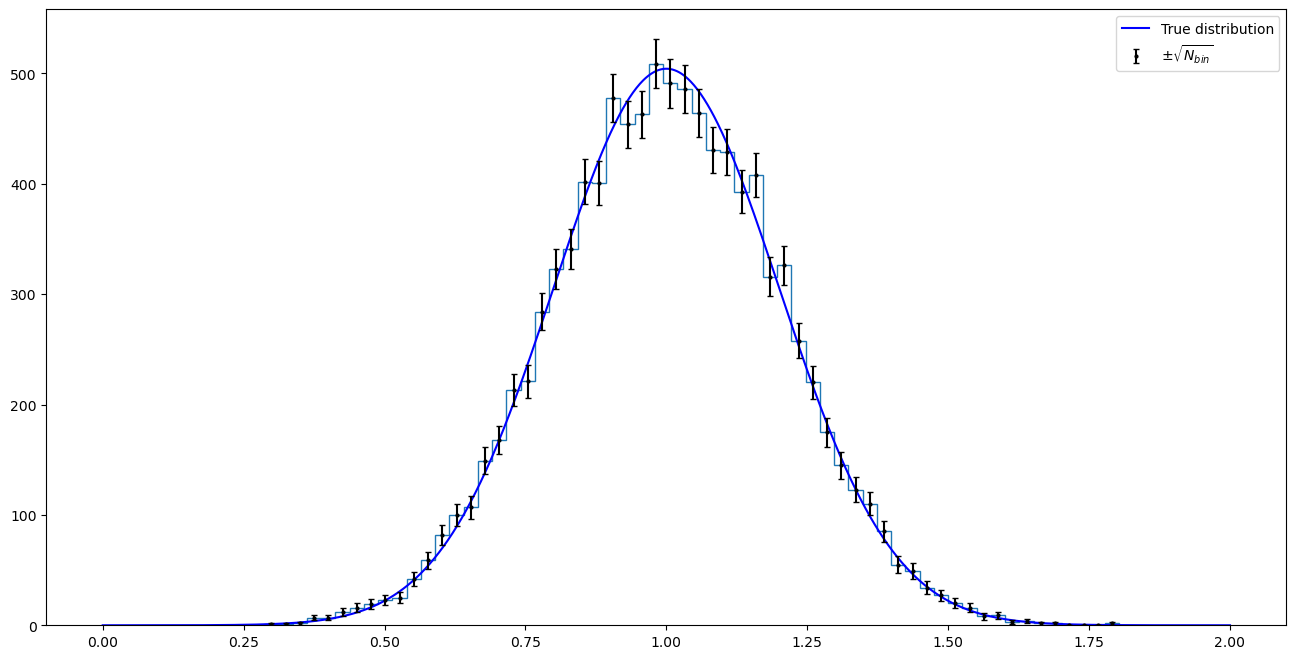

In [2]:
# Sample generation
mu = 1.0
sigma = 0.2
num_sample = 10000
np.random.seed(324)
x_1 = norm(mu, sigma).rvs(num_sample)
# Hist
counts, bin_edges = np.histogram(x_1, bins="fd")
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
# Uncertainty
uncertainty = np.sqrt(counts)
# Gaussian 
xGrid = np.linspace(0, 2, 1000)
gauss = norm(mu, sigma).pdf(xGrid)
gauss_scale = gauss * num_sample * bin_width
# Plot
fig, ax = plt.subplots(figsize=(16, 8))
ax.hist(x_1, bins="fd", histtype="step")
plt.plot(xGrid, gauss_scale, ls='-', c='blue', label='True distribution')
ax.errorbar(bin_centers, counts, yerr=uncertainty, fmt='.', color='black', 
            markersize=4, capsize=2, label=r'$\pm \sqrt{N_{bin}}$')
ax.legend();

## Problem 2

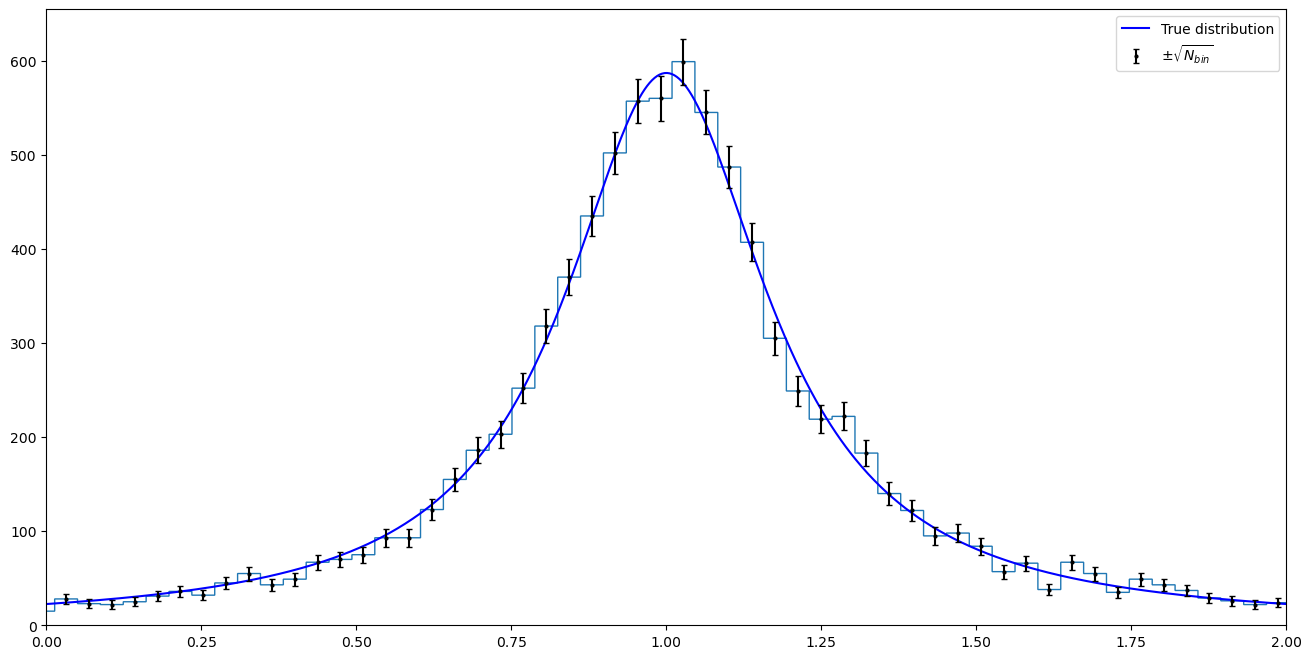

In [3]:
# Sample generation
mu = 1.0
gamma = 0.2
num_sample = 10000
np.random.seed(324)
x_2 = cauchy(mu, gamma).rvs(num_sample)
# Hist
counts, bin_edges = np.histogram(x_2, bins="fd")
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
# Uncertainty
uncertainty = np.sqrt(counts)
# Gaussian 
xGrid = np.linspace(0, 2, 1000)
cauchy_pdf = cauchy(mu, gamma).pdf(xGrid)
cauchy_scale = cauchy_pdf * num_sample * bin_width
# Plot
fig, ax = plt.subplots(figsize=(16, 8))
ax.hist(x_2, bins="fd", histtype="step")
plt.plot(xGrid, cauchy_scale, ls='-', c='blue', label='True distribution')
ax.errorbar(bin_centers, counts, yerr=uncertainty, fmt='.', color='black', 
            markersize=4, capsize=2, label=r'$\pm \sqrt{N_{bin}}$')
ax.set_xlim(0, 2)
ax.legend();

## Problem 3

In [4]:
p1_sam_mean = np.mean(x_1)
p1_std_err = sem(x_1)
p2_sam_mean = np.mean(x_2)
p2_std_err = sem(x_2)
print(f"""Problem 1 has a sample mean of {p1_sam_mean:.2f}±{p1_std_err:.4f}.
Problem 2 has a sample mean of {p2_sam_mean:.2f}±{p2_std_err:.2f}.""")

Problem 1 has a sample mean of 1.00±0.0020.
Problem 2 has a sample mean of 0.87±0.25.


Sample mean of the normal distribution converges to the true mean with small uncertaintly. Sample mean of the Cauchy distribution does not converge as it is dominated by extreme outliers.

## Problem 4

In [5]:
# <F
p_sys_f = 0.1 * 0.1
# G
p_sys_g = 0.15 * 0.3
# K
p_sys_k = 0.45 * 0.25
# >M
p_sys_m = 0.7 * 0.5

total_prob = p_sys_f + p_sys_g + p_sys_k + p_sys_m

print(f"The probability a randomly chosen main sequence star will harbor a planetary system is {total_prob}.")

The probability a randomly chosen main sequence star will harbor a planetary system is 0.5175.


## Problem 5

In [6]:
# Sample 1 generation
mu_1 = 1.0
sigma_1 = 0.1
num_sample_1 = 100
np.random.seed(324)
x_1 = norm(mu_1, sigma_1).rvs(num_sample_1)
# Sample 2 generation
mu_2 = 10.0
sigma_2 = 1.0
num_sample_2 = 3
np.random.seed(228)
x_2 = norm(mu_2, sigma_2).rvs(num_sample_2)
# Total sample
x_tot = np.append(x_1, x_2)
sam_mean = np.mean(x_tot)
sam_median = np.median(x_tot)
print(f"The mean of the extended sample is {sam_mean:.2f} and the median is {sam_median:.2f}.")

The mean of the extended sample is 1.24 and the median is 0.99.


The mean and the median of the extended sample are not similar. The mean is larger than the true distribution of the majority of the sample (N = 100), as it is skewed by the three outliers. The median still captures the average of most of the sample, as it is very close to 1, which is the location parameter of the true distribution.

## Problem 6

The chances of picking the door with the car is 1/2.

## Problem 7

According to Bayes' theorem, the probability of y given x is:
$$p(y|x) = \frac{p(x|y)p(y)}{p(x)}$$
In the context of this problem (Assume the player picked door 1), the probability of car behind door 1 given the host opens door 3 is:
$$p(car\,d1|open\,d3) = \frac{p(open\,d3|car\,d1)p(car\,d1)}{p(open\,d3)}$$
Lets solve $p(open\,d3|car\,d1)$ first.
The host can only open doors without a car, in this case the host can only pick door 2 or door 3, so the probability is:
$$p(open\,d3|car\,d1) = 1/2$$
Next, the probability of car behind door 1 is:
$$p(car\,d1) = 1/3$$
Last, the probability of opening door 3, we can use the law of total probability:
$$p(A) = \sum_ip(A|B_i)p(B_i)$$
And in context of this problem:
$$p(open\,d3) = \sum_{i=1}^3 p(open\,d3|car\,d_i)p(car\,d_i)$$
$$p(open\,d3) = p(open\,d3|car\,d1)p(car\,d1) + p(open\,d3|car\,d2)p(car\,d2) + p(open\,d3|car\,d3)p(car\,d3)$$
$p(open\,d3|car\,d1)$ was calculated above. $p(open\,d3|car\,d2)$ is 1 because door 1 was picked and car is behind door 2, leaving door 3 the only option. $p(open\,d3|car\,d3)$ is 0 because the host can't reveal the car.
$$p(open\,d3) = \frac{1}{2} \cdot \frac{1}{3} + 1 \cdot \frac{1}{3} + 0 \cdot \frac{1}{3} = \frac{1}{2}$$
Putting it all together:
$$p(car\,d1|open\,d3) = \frac{\frac{1}{2} \cdot \frac{1}{3}}{\frac{1}{2}}$$
$$p(car\,d1|open\,d3) = \frac{1}{3}$$
The player should switch doors because the probability of getting a car after switching is $1-p(car\,d1|open\,d3)=\frac{2}{3}$.

## Problem 8

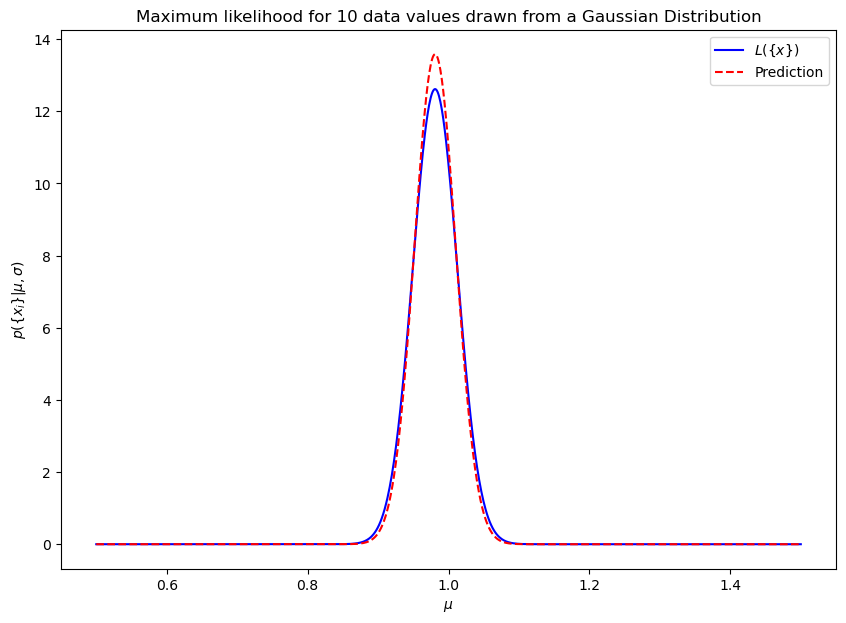

In [22]:
mu = 1.0
sigma = 0.1
num_sample = 10
np.random.seed(2026)
sample = norm(mu, sigma).rvs(num_sample)
mu_grid = np.linspace(0.5,1.5,1000)
max_likelihood = 1

fig, ax = plt.subplots(figsize=(10, 7))
for i in range(0,num_sample):
    likelihood = norm(sample[i], sigma).pdf(mu_grid)
    max_likelihood *= likelihood 
area = np.trapz(max_likelihood, mu_grid)
normalized_likelihood = max_likelihood / area

sam_mean = np.mean(sample)
std_err = sem(sample)
prediction_pdf = norm(sam_mean, std_err).pdf(mu_grid)

plt.plot(mu_grid, normalized_likelihood, ls='-', c='blue', label=r'$L(\{x\})$')
plt.plot(mu_grid, prediction_pdf, ls='--', c='red', label='Prediction')

plt.xlabel(r'$\mu$')
plt.ylabel(r'$p(\{x_i\}|\mu,\sigma)$')
plt.title('Maximum likelihood for 10 data values drawn from a Gaussian Distribution')
plt.legend()
plt.show();



Both distributions are approximately the same, with the gaussian prediction having a slightly higher pd and slightly smaller width. Both the predicted mu and MLE mu have almost the same value and are both slightly smaller than 1.0, the true mu, probably a result of random draw with small sample size.

## Problem 9

In [45]:
# modeled after code by Jake VanderPlas:
# https://www.astroml.org/book_figures/chapter5/fig_posterior_binomial.html
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)

def doBinomial(n=10, k=3, target=0.5):
    
    import numpy as np
    from scipy.stats import norm, binom
    from matplotlib import pyplot as plt

    b = np.linspace(0, 1, 10000)
    db = b[1] - b[0]

    # compute the probability p(b) (eqn. 5.70)
    p_b = b ** k * (1 - b) ** (n - k)
    p_b /= p_b.sum()
    p_b /= db
    cuml_p_b = p_b.cumsum()
    cuml_p_b /= cuml_p_b[-1]
    
    prob = np.interp(target, b, cuml_p_b)
    return prob

In [46]:
prob_1 = doBinomial(10, 3, 0.5)
prob_2 = doBinomial(100, 30, 0.5)
prob_3 = doBinomial(1000, 300, 0.5)
print(f"""
      The probability that no more than 50% of galaxies harbor black holes is:
      {prob_1:.3f} for (n=10, k=3),
      {prob_2:.5f} for (n=100, k=30), 
      and {prob_3:.3f} for (n=1000, k=300).
      """)


      The probability that no more than 50% of galaxies harbor black holes is:
      0.887 for (n=10, k=3),
      0.99997 for (n=100, k=30), 
      and 1.000 for (n=1000, k=300).
      
